In [92]:
import os
from datasets import Dataset
from torchvision.transforms import Compose, Resize, ToTensor, Grayscale, Lambda
import torch
from torch.utils.data import Dataset, DataLoader
import numpy as np
from datasets import load_from_disk, load_dataset
from PIL import Image
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import optim

In [93]:
Labels = ["real", "synthetic", "tampered"]

In [94]:
dir = "data"
dataset_train = "SID_train"
dataset_test = "SID_test"
dataset_dir = lambda x: os.path.join(dir, x)

if dataset_train not in os.listdir("data"):
    print("Saving dataset to disk...")
    streamed_train = load_dataset("saberzl/SID_Set", split="train", streaming=True)
    first_80 = list(streamed_train.take(80))
    dataset_train_data = Dataset.from_list(first_80)
    dataset_train_data.save_to_disk(dataset_dir(dataset_train))

loaded_dataset_train = load_from_disk(dataset_dir(dataset_train))
print(loaded_dataset_train)

if dataset_test not in os.listdir("data"):
    print("Saving test dataset to disk...")
    streamed_test = load_dataset("saberzl/SID_Set", split="validation", streaming=True)
    first_20 = list(streamed_test.take(20))
    dataset_test_data = Dataset.from_list(first_20)
    dataset_test_data.save_to_disk(dataset_dir(dataset_test))

loaded_dataset_test = load_from_disk(dataset_dir(dataset_test))
print(loaded_dataset_train)


Dataset({
    features: ['img_id', 'image', 'mask', 'width', 'height', 'label'],
    num_rows: 80
})
Dataset({
    features: ['img_id', 'image', 'mask', 'width', 'height', 'label'],
    num_rows: 80
})


In [95]:
Width, Height = 256, 256
ImageSize = (Width, Height)

# 1. Create a transform pipeline
image_transform = Compose([
    Resize(ImageSize), # resize to fixed size
    # Force convert any image to RGB (3 channels), since some are grayscale
    Lambda(lambda img: img.convert("RGB") if isinstance(img, Image.Image) else img), 
    ToTensor()
])

mask_transform = Compose([
    Resize(ImageSize),
    Grayscale(num_output_channels=1),  # force 1 channel
    ToTensor()                         # yields shape (1,256,256)
])

class HFDataset(Dataset):
    def __init__(self, hf_ds, device=None):
        self.ds = hf_ds
        self.device = device

    def __len__(self):
        return len(self.ds)

    def __getitem__(self, idx):
        ex = self.ds[idx]

        # Transform image
        img = image_transform(ex["image"])  # → tensor shape (3,256,256)
        #print(f"Image shape: {img.shape}, Type: {type(img)}, Dtype: {img.dtype}, Min: {img.min().item()}, Max: {img.max().item()}")

        # Transform mask if present
        if ex["mask"] is not None:
            mask = mask_transform(ex["mask"])
        else:
            mask = torch.zeros((1,256,256), dtype=torch.float)
        #print(f"Mask shape: {mask.shape}, Type: {type(mask)}, Dtype: {mask.dtype}, Min: {mask.min().item()}, Max: {mask.max().item()}")

        label = torch.tensor(ex["label"], dtype=torch.long)
        #print(f"Label: {label}, Type: {type(label)}, Value: {label.item()}")

        if self.device:
            img, mask, label = img.to(self.device), mask.to(self.device), label.to(self.device)
        return {"image": img, "mask": mask, "label": label}

In [96]:


device = torch.device("cuda") if torch.cuda.is_available() else None
wrapped = HFDataset(loaded_dataset_train, device=device)

train_loader = DataLoader(
    wrapped,
    batch_size=20,
    shuffle=True,
    num_workers=0,     # adjust based on your CPU cores
    pin_memory=bool(device)
)
train_iter = next(iter(train_loader))
print(f"Batch of images: {train_iter['image'].shape}, Batch of masks: {train_iter['mask'].shape}, Batch of labels: {train_iter['label'].shape}")


train_iter = next(iter(train_loader))
print(f"Batch of images: {train_iter['image'].shape}")  # → (batch_size,3,256,256)
print(f"Batch of masks: {train_iter['mask'].shape}")   # → (batch_size,1,256,256)


Batch of images: torch.Size([20, 3, 256, 256]), Batch of masks: torch.Size([20, 1, 256, 256]), Batch of labels: torch.Size([20])
Batch of images: torch.Size([20, 3, 256, 256])
Batch of masks: torch.Size([20, 1, 256, 256])


In [97]:
test_set = HFDataset(loaded_dataset_test, device=device)
test_loader = DataLoader(
    test_set,
    batch_size=20,
    shuffle=True,
    num_workers=0,
    pin_memory=bool(device),
)
test_iter = next(iter(test_loader))
print(f"Batch of images: {test_iter['image'].shape}, Batch of masks: {test_iter['mask'].shape}, Batch of labels: {test_iter['label'].shape}")

Batch of images: torch.Size([20, 3, 256, 256]), Batch of masks: torch.Size([20, 1, 256, 256]), Batch of labels: torch.Size([20])


In [98]:
# 1. Define a simple CNN
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=3):  # adjust num_classes as needed
        super().__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.pool  = nn.MaxPool2d(2)
        self.fc1   = nn.Linear(32 * 64 * 64, 128)  # 256→128 after pooling twice
        self.fc2   = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))  # → (16,128,128)
        x = self.pool(F.relu(self.conv2(x)))  # → (32,64,64)
        x = x.view(x.size(0), -1)             # flatten
        x = F.relu(self.fc1(x))
        return self.fc2(x)

In [99]:
# 2. Instantiate model, loss, optimizer
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SimpleCNN(num_classes=3).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

In [100]:
# 3. Training loop
num_epochs = 5
for epoch in range(1, num_epochs + 1):
    model.train()
    running_loss = 0.0
    for batch in test_loader:
        images = batch["image"].to(device)   # (B,3,256,256)
        labels = batch["label"].to(device)   # (B,)

        optimizer.zero_grad()
        outputs = model(images)              # (B,num_classes)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

    epoch_loss = running_loss / len(test_loader.dataset)
    print(f"Epoch {epoch}/{num_epochs} — Loss: {epoch_loss:.4f}")

Epoch 1/5 — Loss: 1.0908
Epoch 2/5 — Loss: 6.4572
Epoch 3/5 — Loss: 1.5241
Epoch 4/5 — Loss: 1.3744
Epoch 5/5 — Loss: 1.0735


In [101]:
# 4. Simple evaluation on one batch
model.eval()
with torch.no_grad():
    sample = next(iter(test_loader))
    imgs = sample["image"].to(device)
    labs = sample["label"].to(device)
    preds = model(imgs).argmax(dim=1)
    accuracy = (preds == labs).float().mean().item()
    print(f"Sample batch accuracy: {accuracy*100:.1f}%")
    print(f"Predictions: {[Labels[i] for i in preds.cpu().numpy()]}")


Sample batch accuracy: 65.0%
Predictions: ['synthetic', 'synthetic', 'synthetic', 'real', 'real', 'synthetic', 'real', 'real', 'real', 'real', 'synthetic', 'synthetic', 'real', 'real', 'real', 'real', 'synthetic', 'real', 'synthetic', 'synthetic']


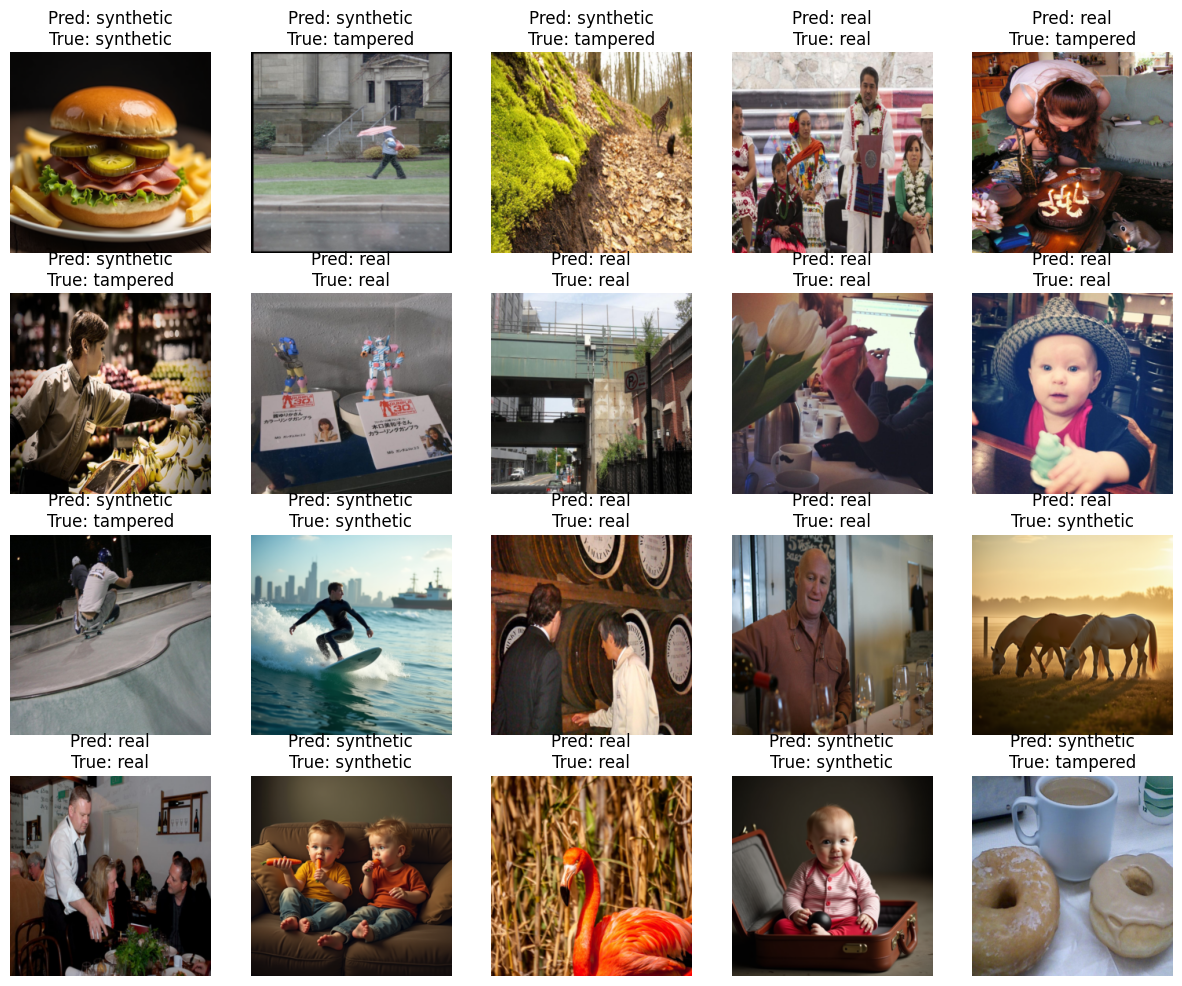

In [102]:
# Print out the evaluated batch predictions the images and the labels
import matplotlib.pyplot as plt
fig, axes = plt.subplots(4, 5, figsize=(15, 12))
for i, ax in enumerate(axes.flat):
    if i < len(imgs):
        img = imgs[i].cpu().permute(1, 2, 0).numpy()  # Convert to HWC for plotting
        ax.imshow(img)
        ax.set_title(f"Pred: {Labels[preds[i].item()]}\nTrue: {Labels[labs[i].item()]}")
        ax.axis('off')
    else:
        ax.axis('off')

In [103]:
# Check mask overlap for tampered predictions
def visualize_mask_overlap(imgs, masks, preds, labs, labels_dict, num_samples=4):
    """
    Visualize predicted tampered images with their masks to check overlap
    """
    # Find indices where prediction is 'tampered' (assuming label 2 is tampered)
    tampered_pred_idx = [i for i in range(len(preds)) if preds[i].item() == 2]
    
    if len(tampered_pred_idx) == 0:
        print("No tampered predictions found in this batch")
        return
    
    # Limit to first few tampered predictions
    tampered_pred_idx = tampered_pred_idx[:min(num_samples, len(tampered_pred_idx))]
    
    fig, axes = plt.subplots(len(tampered_pred_idx), 3, figsize=(12, 4*len(tampered_pred_idx)))
    if len(tampered_pred_idx) == 1:
        axes = axes.reshape(1, -1)
    
    for row, idx in enumerate(tampered_pred_idx):
        # Original image
        img = imgs[idx].cpu().permute(1, 2, 0).numpy()
        img = np.clip(img, 0, 1)  # Ensure values are in [0,1] range
        
        # Mask
        mask = masks[idx].cpu().squeeze().numpy()  # Remove channel dimension
        
        # Predicted vs True labels
        pred_label = labels_dict[preds[idx].item()]
        true_label = labels_dict[labs[idx].item()]
        
        # Plot original image
        axes[row, 0].imshow(img)
        axes[row, 0].set_title(f'Original Image\nPred: {pred_label}, True: {true_label}')
        axes[row, 0].axis('off')
        
        # Plot mask
        axes[row, 1].imshow(mask, cmap='gray')
        axes[row, 1].set_title('Tampered Region Mask')
        axes[row, 1].axis('off')
        
        # Plot overlay
        axes[row, 2].imshow(img)
        axes[row, 2].imshow(mask, alpha=0.3, cmap='Reds')  # Red overlay for tampered regions
        axes[row, 2].set_title('Image + Mask Overlay')
        axes[row, 2].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    # Print statistics
    print(f"Found {len(tampered_pred_idx)} tampered predictions in this batch")
    for i, idx in enumerate(tampered_pred_idx):
        mask_coverage = masks[idx].cpu().sum().item() / (masks[idx].shape[1] * masks[idx].shape[2])
        print(f"Sample {i+1}: Mask covers {mask_coverage:.1%} of the image")

# Call this with your current batch data
visualize_mask_overlap(imgs, sample['mask'], preds, labs, Labels)


No tampered predictions found in this batch
